In [1]:
import numpy as np
_dataset_path = "qd/datasets/track_embeddings_metrics_32dim_rngMixDS_tita_circular_7.npz"
EMBEDDING_MODEL_PATH = "qd/embeddings/models/model_metrics_VAE/model_metrics_VAE_mixRng_tita_circular_7.pth"
_data = np.load(_dataset_path)
_embeddings = _data["embeddings"]


# pairwise distances
from scipy.spatial.distance import pdist, squareform
distances = pdist(_embeddings, metric="euclidean")

max_distance = np.max(distances)
min_distance = np.min(distances)
average_distance = np.mean(distances)

diff = max_distance - min_distance
y = diff / min_distance

print(f"Max distance: {max_distance}")
print(f"Min distance: {min_distance}")
print(f"Difference: {diff}")
print(f"Difference / Min distance: {y}")
print(f"Average distance: {average_distance}")

Max distance: 13.851225016957903
Min distance: 0.06090600727045313
Difference: 13.79031900968745
Difference / Min distance: 226.41968547456307
Average distance: 6.435131254589131


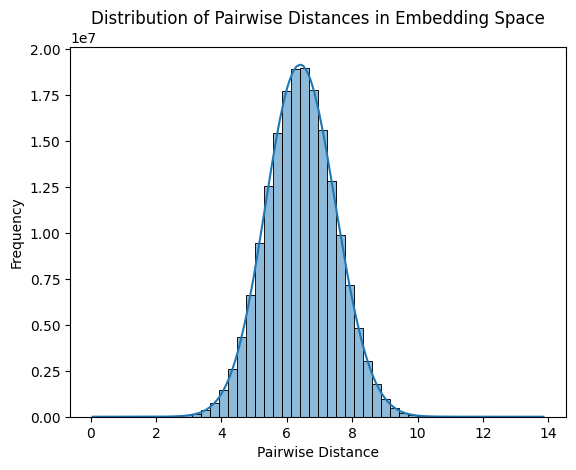

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(distances, bins=50, kde=True)
plt.xlabel("Pairwise Distance")
plt.ylabel("Frequency") 
plt.title("Distribution of Pairwise Distances in Embedding Space")
plt.show()

Dimension 0: Mean = 0.0679, Std Dev = 0.8804
Dimension 1: Mean = -0.1026, Std Dev = 0.9485
Dimension 2: Mean = 0.0712, Std Dev = 0.6575
Dimension 3: Mean = 0.0171, Std Dev = 0.1004
Dimension 4: Mean = -0.1178, Std Dev = 0.8952
Dimension 5: Mean = 0.0292, Std Dev = 0.9699
Dimension 6: Mean = 0.0129, Std Dev = 0.9864
Dimension 7: Mean = 0.0188, Std Dev = 0.1376
Dimension 8: Mean = 0.0660, Std Dev = 0.9242
Dimension 9: Mean = -0.0826, Std Dev = 0.9390
Dimension 10: Mean = -0.0033, Std Dev = 0.2075
Dimension 11: Mean = 0.0379, Std Dev = 0.9171
Dimension 12: Mean = 0.0196, Std Dev = 0.9350
Dimension 13: Mean = 0.0302, Std Dev = 0.9307
Dimension 14: Mean = -0.0152, Std Dev = 0.9205
Dimension 15: Mean = 0.0600, Std Dev = 0.0847
Dimension 16: Mean = -0.0021, Std Dev = 0.1606
Dimension 17: Mean = -0.0125, Std Dev = 0.0435
Dimension 18: Mean = 0.0887, Std Dev = 0.9592
Dimension 19: Mean = 0.0577, Std Dev = 0.9529
Dimension 20: Mean = -0.0072, Std Dev = 0.9231
Dimension 21: Mean = -0.0716, Std De

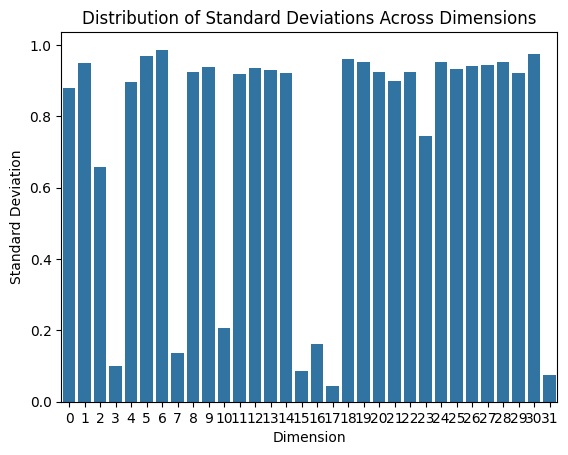

In [3]:
# for each dimention calculate the mean and std_deviation
for i in range(_embeddings.shape[1]):
    dim_values = _embeddings[:, i]
    mean = np.mean(dim_values)
    std_dev = np.std(dim_values)
    print(f"Dimension {i}: Mean = {mean:.4f}, Std Dev = {std_dev:.4f}")
    
# make a barplot of the std_deviation of each dimension
std_devs = [np.std(_embeddings[:, i]) for i in range(_embeddings.shape[1])]
sns.barplot(x=list(range(len(std_devs))), y=std_devs)
plt.xlabel("Dimension")
plt.ylabel("Standard Deviation")
plt.title("Distribution of Standard Deviations Across Dimensions")
plt.show()

Autovalori: [5.04642195e-02 1.04590934e-02 4.41066917e-03 3.24168372e-03
 1.54885503e-03 1.00618965e-03 4.86478163e-04 6.41053282e-04
 1.23603517e+00 5.31136258e-01 1.16798457e+00 5.94645309e-01
 6.00067827e-01 1.13074674e+00 1.12600666e+00 6.29760673e-01
 1.08306184e+00 1.06207733e+00 1.03783579e+00 1.01340666e+00
 9.90260046e-01 6.73108433e-01 7.17578170e-01 7.25955460e-01
 9.49763055e-01 9.27950024e-01 9.10670155e-01 7.65401375e-01
 8.64914214e-01 8.36065086e-01 8.03807094e-01 8.07892193e-01]


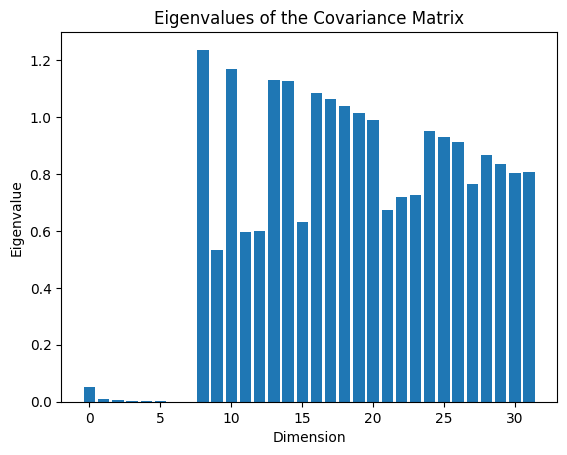

In [4]:
# covariance matrix and eigenvalues
cov_matrix = np.cov(_embeddings, rowvar=False)
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
print("Autovalori:", eigenvalues)

# bar plot of eigenvalues
plt.bar(range(len(eigenvalues)), eigenvalues)
plt.xlabel("Dimension")
plt.ylabel("Eigenvalue")
plt.title("Eigenvalues of the Covariance Matrix")
plt.show()